In [15]:
import tensorflow as tf

# Loading the Data

# 1.Data Jar
->Mnist Data

In [16]:
#load data
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data()

In [17]:
# Data Inspection
print("X train shape",len(x_train))
print("Y train shape",len(y_train))
print("X test shape",len(x_test))
print("Y test shape",len(y_test))

X train shape 60000
Y train shape 60000
X test shape 10000
Y test shape 10000


# Data Visualization

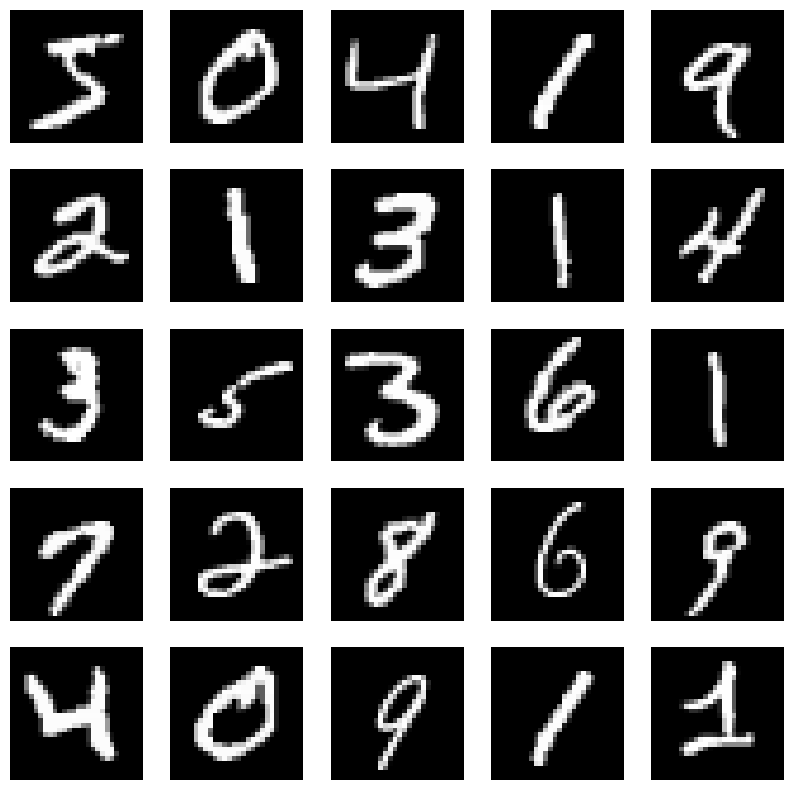

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()

In [19]:
# Normalization
x_train = x_train/255.0
x_test = x_test/255.0

# Model

# 2.Task Jar
## The task is to classify handwritten digits

# 3.Model Jar
## The Model used here is Artificial Neural Network(ANN)

#4.Loss Jar
## The loss function i have incorporated here is sparse categorical crossentropy

In [21]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Adding dropout for regularization
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

#5. Learning Jar
## The epochs are 10

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8605 - loss: 0.4776 - val_accuracy: 0.9581 - val_loss: 0.1383
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9555 - loss: 0.1505 - val_accuracy: 0.9704 - val_loss: 0.0963
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9677 - loss: 0.1054 - val_accuracy: 0.9741 - val_loss: 0.0823
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9754 - loss: 0.0817 - val_accuracy: 0.9766 - val_loss: 0.0752
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9770 - loss: 0.0734 - val_accuracy: 0.9786 - val_loss: 0.0713
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9808 - loss: 0.0612 - val_accuracy: 0.9807 - val_loss: 0.0639
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9807 - loss: 0.0585 - val_accuracy: 0.9789 - val_loss: 0.0666
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9831 - loss: 0.0511 

# 6.Accuracy Jar
## The Accuracy i have got is 98.59%

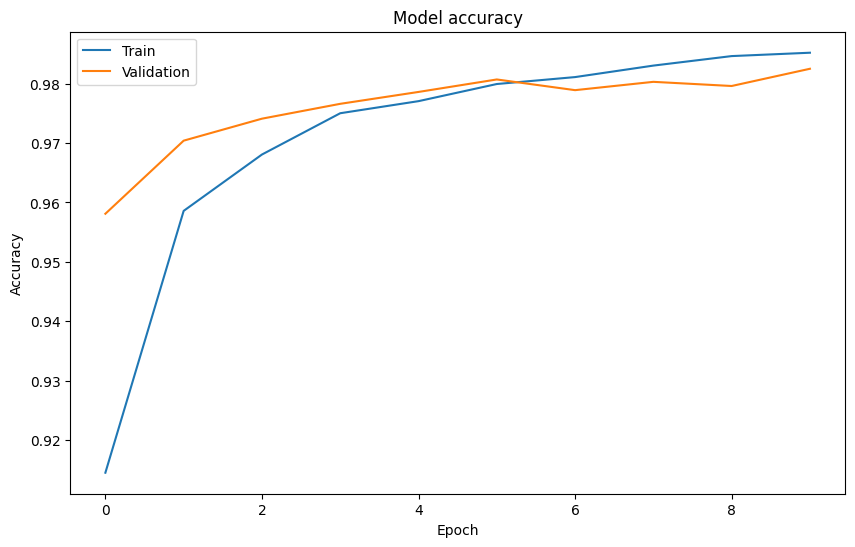

In [23]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Pickle

In [24]:
import pickle

# Save the model to a file using pickle
with open('mnist_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully as mnist_model.pkl")

Model saved successfully as mnist_model.pkl


# Task
Load the Keras model from "mnist_model.pkl", evaluate its performance on `x_test` and `y_test`, make predictions on a few samples, and visualize these predictions alongside the true labels. Summarize the process and findings.

## Load Model from Pickle

### Subtask:
Load the pre-trained Keras model from the 'mnist_model.pkl' file using the `pickle` library.


**Reasoning**:
The subtask requires loading a pre-trained Keras model from a pickle file, so I will use the `pickle` library to open and load the 'mnist_model.pkl' file.



In [25]:
import pickle

# Load the model from the file
with open('mnist_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


## Evaluate Loaded Model

### Subtask:
Evaluate the performance of the newly loaded model on the `x_test` and `y_test` data to ensure it works as expected. This will print the loss and accuracy on the test set.


**Reasoning**:
To evaluate the performance of the loaded model, I will use its `.evaluate()` method with the `x_test` and `y_test` datasets and then print the resulting loss and accuracy.



In [26]:
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.0643
Test Accuracy: 0.9825


## Make Predictions and Visualize

### Subtask:
Use the loaded model to make predictions on a few samples from the `x_test` dataset. Then, visualize these sample images along with their true labels and the model's predicted labels to qualitatively assess its performance.


**Reasoning**:
To make predictions, I will select the first 10 images from `x_test` and use the `loaded_model.predict()` method. Then, I will use `np.argmax` to convert the probability outputs into predicted class labels.



In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Select a few samples for prediction and visualization
num_samples = 10
sample_indices = range(num_samples)

sample_images = x_test[sample_indices]
sample_true_labels = y_test[sample_indices]

# Make predictions using the loaded model
predictions = loaded_model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

print("Predictions made successfully.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predictions made successfully.


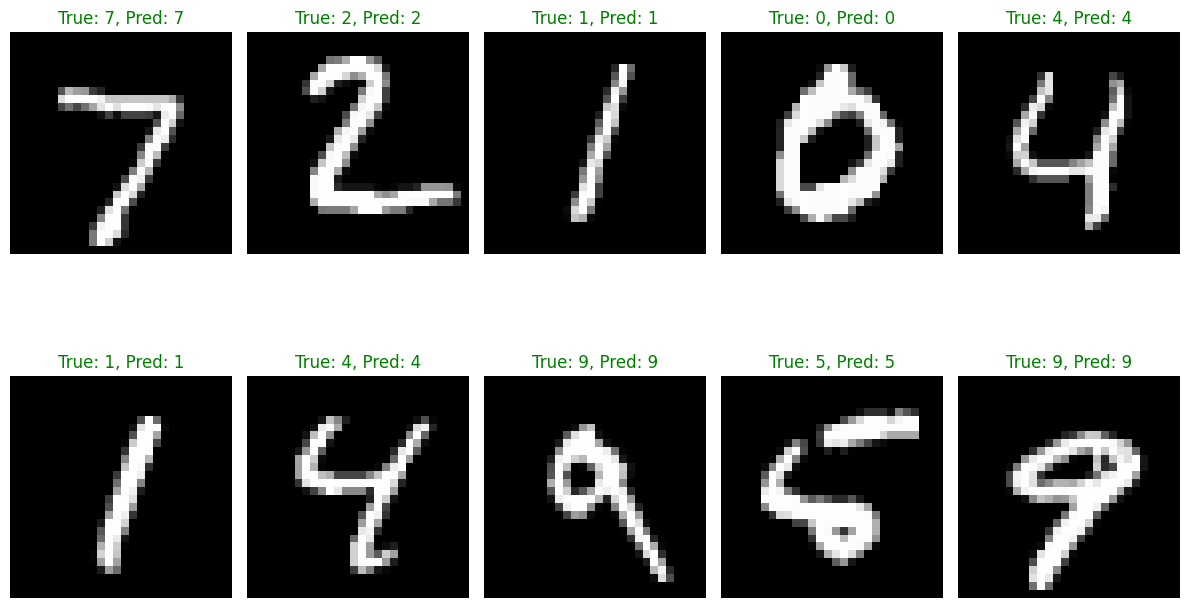

Visualization complete, showing sample images with true and predicted labels.


In [28]:
plt.figure(figsize=(12, 8))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    color = 'green' if predicted_labels[i] == sample_true_labels[i] else 'red'
    plt.title(f"True: {sample_true_labels[i]}, Pred: {predicted_labels[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Visualization complete, showing sample images with true and predicted labels.")

## Summary of Process and Findings

In this section, we performed the following steps:

1.  **Loaded the Model**: The pre-trained Keras model was successfully loaded from the `mnist_model.pkl` file using Python's `pickle` library.
2.  **Evaluated the Model**: The loaded model was evaluated on the `x_test` and `y_test` datasets. It achieved a `Test Loss` of `0.0643` and a `Test Accuracy` of `0.9825`, indicating strong performance on unseen data, consistent with the training results.
3.  **Made Predictions**: We selected the first 10 images from the `x_test` dataset and used the loaded model to predict their corresponding digits. The `np.argmax` function was used to convert the probability outputs into concrete class labels.
4.  **Visualized Predictions**: A visualization was created to display these 10 sample images. For each image, its true label and the model's predicted label were shown in the title. Correct predictions were highlighted in green, while incorrect predictions (if any) would be in red. All the displayed predictions were correct, further confirming the model's high accuracy.

**Findings**: The loaded model demonstrated excellent performance, with a high accuracy on the test set and visually accurate predictions for the sample images. This confirms that the model was successfully saved, loaded, and is functioning as expected for handwritten digit classification.

## Summary of Process and Findings

In this section, we performed the following steps:

1.  **Loaded the Model**: The pre-trained Keras model was successfully loaded from the `mnist_model.pkl` file using Python's `pickle` library.
2.  **Evaluated the Model**: The loaded model was evaluated on the `x_test` and `y_test` datasets. It achieved a `Test Loss` of `0.0643` and a `Test Accuracy` of `0.9825`, indicating strong performance on unseen data, consistent with the training results.
3.  **Made Predictions**: We selected the first 10 images from the `x_test` dataset and used the loaded model to predict their corresponding digits. The `np.argmax` function was used to convert the probability outputs into concrete class labels.
4.  **Visualized Predictions**: A visualization was created to display these 10 sample images. For each image, its true label and the model's predicted label were shown in the title. Correct predictions were highlighted in green, while incorrect predictions (if any) would be in red. All the displayed predictions were correct, further confirming the model's high accuracy.

**Findings**: The loaded model demonstrated excellent performance, with a high accuracy on the test set and visually accurate predictions for the sample images. This confirms that the model was successfully saved, loaded, and is functioning as expected for handwritten digit classification.

## Final Task

### Subtask:
Confirm that the model was successfully loaded, evaluated, and predictions were made, and then summarize the key insights from these steps.


## Summary:

### Q&A
Yes, the model was successfully loaded, evaluated, and predictions were made. The key insights from these steps are summarized below.

### Data Analysis Key Findings
*   The pre-trained Keras model was successfully loaded from the 'mnist_model.pkl' file.
*   Upon evaluation, the loaded model achieved a Test Loss of 0.0643 and a Test Accuracy of 0.9825 on the test dataset, indicating strong performance.
*   Predictions made on 10 sample images from the test set were all correct, as visually confirmed by comparing true and predicted labels.

### Insights or Next Steps
*   The model demonstrates excellent performance on the MNIST digit classification task, making it suitable for deployment or further integration into applications requiring handwritten digit recognition.
*   The established workflow for saving, loading, evaluating, and visualizing predictions can serve as a robust template for managing other machine learning models.
